<a href="https://colab.research.google.com/github/ShreyasT123/ShreyasT123/blob/main/linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])
<generator object Module.parameters at 0x7a114a8436f0>
OrderedDict([('weights', tensor([0.8999])), ('bias', tensor([0.4001]))])


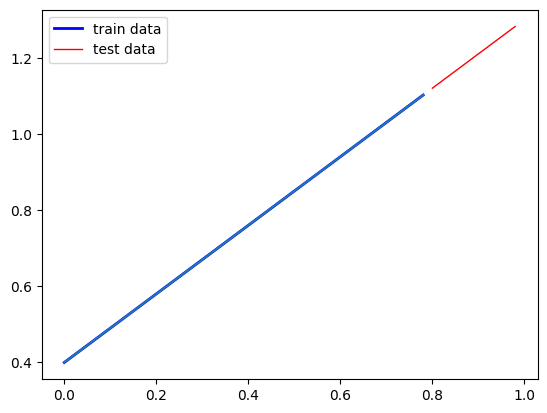

In [64]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt
# Create *known* parameters
weight = 0.9
bias = 0.4

# Create data
X = torch.arange(0,1, 0.02).unsqueeze(dim=1)
y = weight * X + bias
train_split=0.8*len(X)
X_train=X[:int(train_split)]
y_train=y[:int(train_split)]
X_test=X[int(train_split):]
y_test=y[int(train_split):]
#Visualising data
plt.plot(X_train,y_train,c='b',linewidth=2,label='train data')
plt.plot(X_test,y_test,c='r',linewidth=1,label='test data')
plt.legend()
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float,requires_grad=True))

        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float,requires_grad=True)) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor):
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)
#build model
torch.manual_seed(42)
model1=LinearRegressionModel()
print(model1.state_dict())
print(model1.parameters())
# Create the loss function
loss_fn = nn.MSELoss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.Adam(params=model1.parameters(),lr=0.2)
lossfn=torch.nn.MSELoss()
epochs =1000
for epoch in range(epochs):
    model1.train()
    y_pred=model1(X_test)
    Loss=loss_fn(y_test,y_pred)
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()
print(model1.state_dict())
W=model1.state_dict()['weights']
B=model1.state_dict()['bias']
Y=W*X+B
Y2=Y[:int(0.8*len(Y))]
plt.plot(X_train,Y2)